# =========================
# 1. Import Library
# =========================



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib

# =========================
# 2. Load Dataset
# =========================

In [2]:
file_id = '1h_z2RXPoKrvvdwO5coIU_-XHIPkwgZe4'

# 2. Buat URL direct download
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# 3. Baca CSV langsung dari link tersebut
df = pd.read_csv(url)
df


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# =========================
# 3. Data Understanding
# =========================

In [3]:


print("Jumlah baris dan kolom:", df.shape)

print("\nInformasi dataset:")
print(df.info())

print("\nStatistik deskriptif:")
display(df.describe())

print("\nCek missing value:")
print(df.isnull().sum())

print("\nCek duplikat:")
print(df.duplicated().sum())

print("\nNama kolom:")
print(df.columns)

Jumlah baris dan kolom: (10000, 12)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None

Statistik deskriptif:


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



Cek missing value:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Cek duplikat:
0

Nama kolom:
Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')


# =========================
# 4. Data Cleaning
# =========================


In [4]:
# Salin data agar data asli tetap aman
data = df.copy()

# Bersihkan nama kolom agar konsisten
data.columns = data.columns.str.strip().str.lower().str.replace(" ", "_")

print(data.columns)

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')


# =========================
# 5. Tentukan Target
# =========================

In [5]:
if "churn" in data.columns:
    target = "churn"
elif "exited" in data.columns:
    target = "exited"
else:
    raise ValueError("Kolom target tidak ditemukan. Cek apakah target bernama 'churn' atau 'exited'.")

print("Target yang digunakan:", target)

Target yang digunakan: churn


# =========================
# 6. Hapus Kolom yang Tidak Relevan
# =========================

In [6]:
drop_columns = []

possible_id_columns = [
    "customer_id",
    "customerid",
    "rownumber",
    "row_number",
    "surname"
]

for col in possible_id_columns:
    if col in data.columns:
        drop_columns.append(col)

data = data.drop(columns=drop_columns)

print("Kolom yang dihapus:", drop_columns)
print("Kolom akhir:", data.columns)

Kolom yang dihapus: ['customer_id']
Kolom akhir: Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'churn'],
      dtype='object')


# =========================
# 7. Cek Ulang Data Setelah Cleaning
# =========================

In [7]:
print("Missing value:")
print(data.isnull().sum())

print("\nJumlah duplikat:")
print(data.duplicated().sum())

data = data.drop_duplicates()

print("Ukuran data setelah hapus duplikat:", data.shape)

Missing value:
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Jumlah duplikat:
0
Ukuran data setelah hapus duplikat: (10000, 11)


# =========================
# 8. Distribusi Target
# =========================


churn
0    7963
1    2037
Name: count, dtype: int64

Persentase:
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


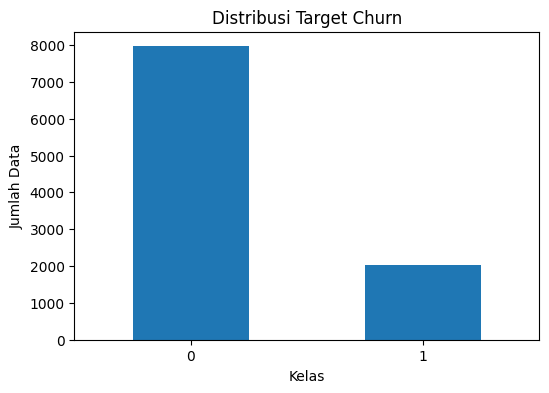

In [8]:
print(data[target].value_counts())
print("\nPersentase:")
print(data[target].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
data[target].value_counts().plot(kind="bar")
plt.title("Distribusi Target Churn")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()

# =========================
# 9. Pisahkan Fitur dan Target
# =========================

In [9]:
X = data.drop(columns=[target])
y = data[target]

print("Fitur:")
print(X.columns)

print("\nTarget:")
print(target)

Fitur:
Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary'],
      dtype='object')

Target:
churn


# =========================
# 10. Identifikasi Kolom Numerik dan Kategorik
# =========================

In [10]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Features:", categorical_features)
print("Numeric Features:", numeric_features)

Categorical Features: ['country', 'gender']
Numeric Features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']


# =========================
# 11. Train-Test Split
# =========================

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 10)
X_test: (2000, 10)
y_train: (8000,)
y_test: (2000,)


# =========================
# 12A. Preprocessing untuk Model Linear
# =========================

In [12]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# =========================
# 12B. Preprocessing untuk Tree-Based Model
# =========================

In [13]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [14]:
# =========================
# 13. Baseline Model: Logistic Regression
# =========================

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", linear_preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_pipeline.fit(X_train, y_train)

y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_logreg))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_logreg))

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

ROC-AUC: 0.7771654551315569


In [15]:
# =========================
# 14. Decision Tree
# =========================

dt_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=5
    ))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)
y_proba_dt = dt_pipeline.predict_proba(X_test)[:, 1]

print("Decision Tree")
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))

Decision Tree
              precision    recall  f1-score   support

           0       0.93      0.77      0.84      1593
           1       0.46      0.77      0.58       407

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.83      0.77      0.79      2000

ROC-AUC: 0.8402863572355097


In [16]:
# =========================
# 15. Model Utama: Random Forest
# =========================

rf_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1593
           1       0.54      0.71      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000

ROC-AUC: 0.8612202341015901


In [17]:
# =========================
# 16. Threshold Tuning - Random Forest
# =========================

threshold = 0.35

# Ubah probabilitas menjadi kelas 0/1 berdasarkan threshold baru
y_pred_rf_threshold = (y_proba_rf >= threshold).astype(int)

print(f"Random Forest - Threshold {threshold}")
print(classification_report(y_test, y_pred_rf_threshold))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest - Threshold 0.35
              precision    recall  f1-score   support

           0       0.95      0.65      0.77      1593
           1       0.38      0.86      0.53       407

    accuracy                           0.69      2000
   macro avg       0.67      0.76      0.65      2000
weighted avg       0.83      0.69      0.72      2000

ROC-AUC: 0.8612202341015901


In [19]:
# =========================
# 17. Perbandingan Model
# =========================

results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_logreg),
        "Precision": precision_score(y_test, y_pred_logreg),
        "Recall": recall_score(y_test, y_pred_logreg),
        "F1-Score": f1_score(y_test, y_pred_logreg),
        "ROC-AUC": roc_auc_score(y_test, y_proba_logreg)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "F1-Score": f1_score(y_test, y_pred_dt),
        "ROC-AUC": roc_auc_score(y_test, y_proba_dt)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-Score": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_proba_rf)
    },
])

results = results.sort_values(by=["F1-Score", "Recall", "ROC-AUC"], ascending=False)

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.8165,0.537175,0.710074,0.611640,0.861220
1,Decision Tree,0.7705,0.461538,0.766585,0.576177,0.840286
0,Logistic Regression,0.7135,0.387228,0.700246,0.498688,0.777165


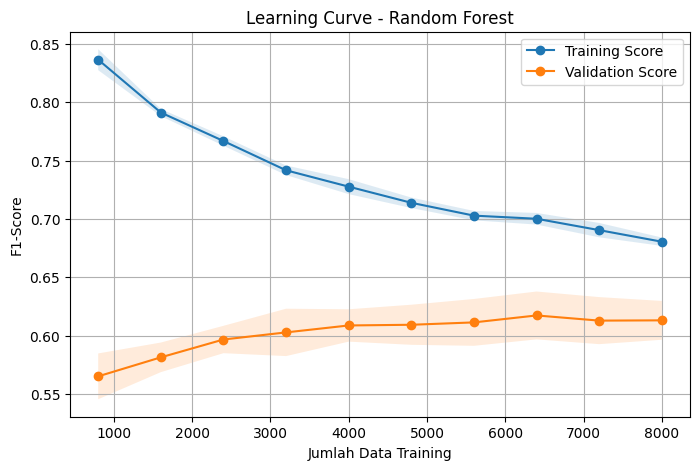

In [20]:
# =========================
# 16. Learning Curve - Random Forest
# =========================

from sklearn.model_selection import learning_curve, StratifiedKFold

# Cross-validation strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Generate learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=rf_pipeline,
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

# Hitung rata-rata dan standar deviasi score
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Plot learning curve
plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation Score"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15
)

plt.title("Learning Curve - Random Forest")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-Score")
plt.legend()
plt.grid(True)
plt.show()

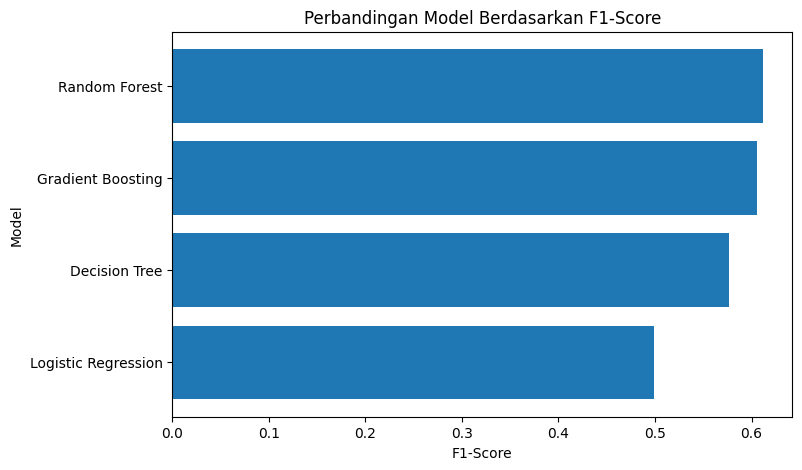

In [21]:
# =========================
# 18. Visualisasi Perbandingan F1-Score
# =========================

plt.figure(figsize=(8, 5))
plt.barh(results["Model"], results["F1-Score"])
plt.xlabel("F1-Score")
plt.ylabel("Model")
plt.title("Perbandingan Model Berdasarkan F1-Score")
plt.gca().invert_yaxis()
plt.show()

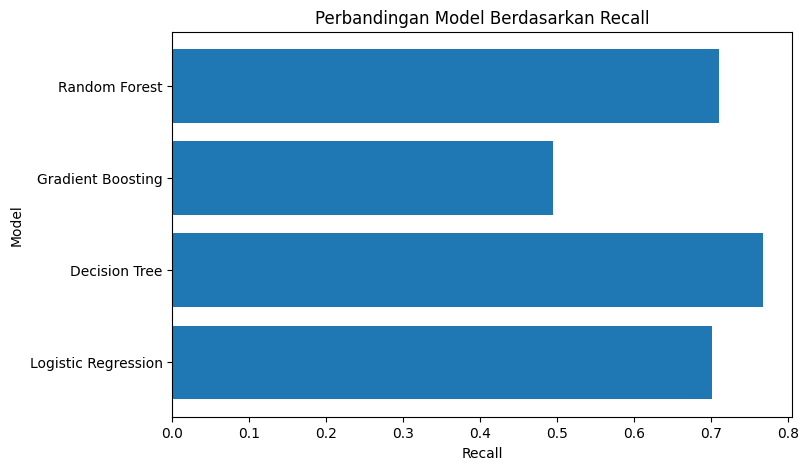

In [22]:
# =========================
# 19. Visualisasi Perbandingan Recall
# =========================

plt.figure(figsize=(8, 5))
plt.barh(results["Model"], results["Recall"])
plt.xlabel("Recall")
plt.ylabel("Model")
plt.title("Perbandingan Model Berdasarkan Recall")
plt.gca().invert_yaxis()
plt.show()

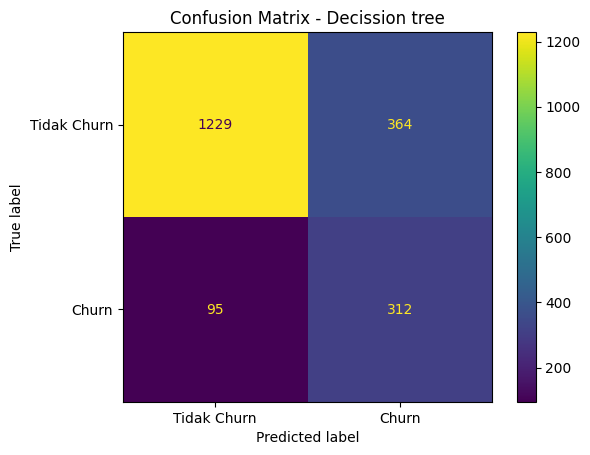

In [23]:
# =========================
# 20. Confusion Matrix - Random Forest
# =========================

cm_rf = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Tidak Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Decission tree")
plt.show()

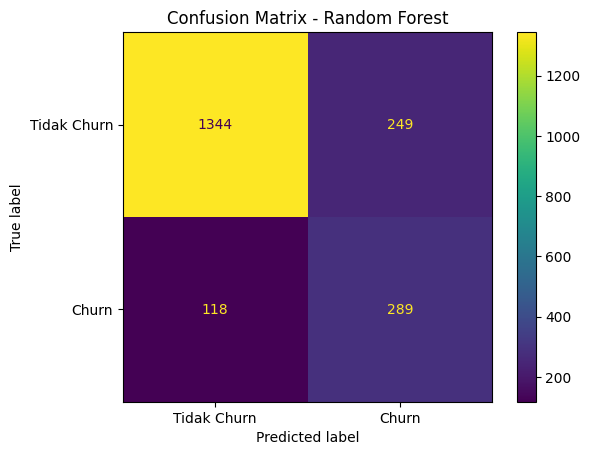

In [24]:
# =========================
# 20. Confusion Matrix - Random Forest
# =========================

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Tidak Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

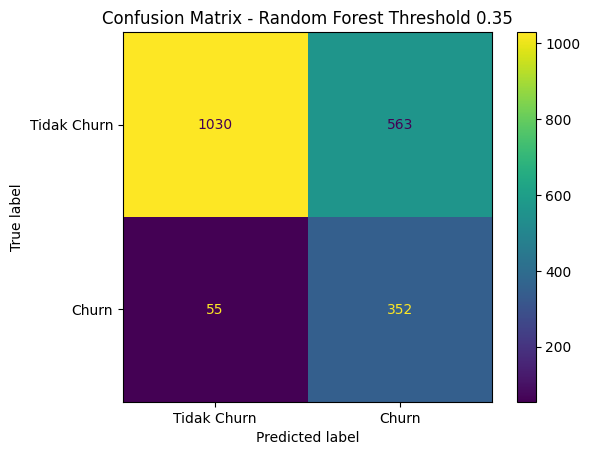

In [25]:
# =========================
# 17. Confusion Matrix - Random Forest dengan Threshold Baru
# =========================

cm_rf_threshold = confusion_matrix(y_test, y_pred_rf_threshold)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_threshold,
    display_labels=["Tidak Churn", "Churn"]
)

disp.plot()
plt.title(f"Confusion Matrix - Random Forest Threshold {threshold}")
plt.show()

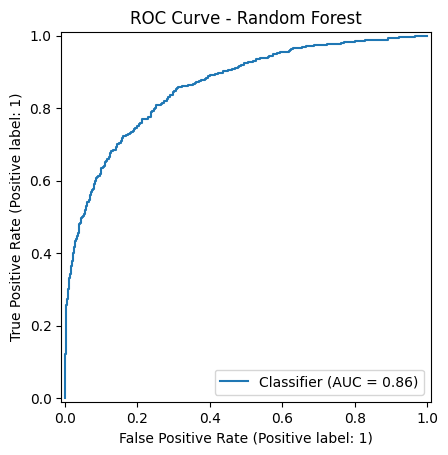

In [26]:
# =========================
# 21. ROC Curve - Random Forest
# =========================

RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("ROC Curve - Random Forest")
plt.show()

In [27]:
# =========================
# 22. Feature Importance - Random Forest
# =========================

# Ambil model Random Forest dari pipeline
rf_model = rf_pipeline.named_steps["model"]

# Ambil nama fitur kategorik setelah one-hot encoding
cat_encoder = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# Gabungkan nama fitur numerik dan kategorik
feature_names = np.concatenate([numeric_features, cat_feature_names])

# Buat dataframe feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
1,age,0.360250
4,products_number,0.234630
3,balance,0.098049
6,active_member,0.063841
9,country_Germany,0.054199
7,estimated_salary,0.049166
0,credit_score,0.048231
2,tenure,0.028350
12,gender_Male,0.016493
11,gender_Female,0.016063


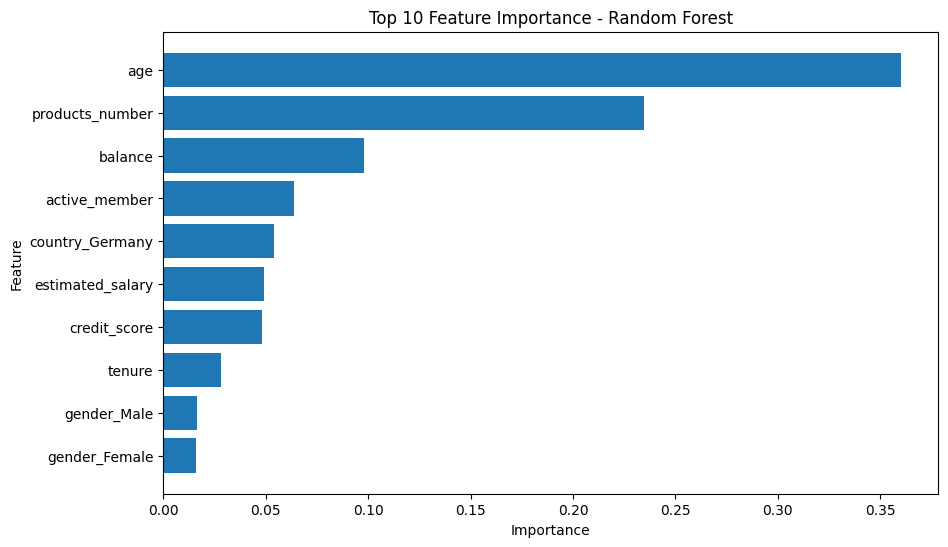

In [28]:
# =========================
# 23. Visualisasi Top 10 Feature Importance
# =========================

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [29]:
joblib.dump(rf_pipeline, "random_forest_churn_model.pkl")

['random_forest_churn_model.pkl']

In [30]:
X_train = pd.DataFrame({
    "credit_score": [600],
    "country": ["France"],
    "gender": ["Female"],
    "age": [42],
    "tenure": [2],
    "balance": [0.00],
    "products_number": [1],
    "credit_card": [1],
    "active_member": [1],
    "estimated_salary": [101348.88]
})

prediction = rf_pipeline.predict(X_train)
probability = rf_pipeline.predict_proba(X_train)[:, 1]

print("Hasil prediksi:", prediction[0])
print("Probabilitas churn:", probability[0])

Hasil prediksi: 1
Probabilitas churn: 0.5574327227671986
